In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [40]:
conn = pyodbc.connect("DRIVER={ODBC Driver 17 for SQL Server};"
                      "SERVER=localhost\\SQLEXPRESS;"
                      "DATABASE=MotoDB;"
                      "Trusted_Connection=yes;")

In [41]:
df = pd.read_sql("SELECT * FROM MotoDB.dbo.VehicleSales", conn)

C:\Users\WorkStation\AppData\Local\Temp\ipykernel_14612\3831369478.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM MotoDB.dbo.VehicleSales", conn)


In [42]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Id              558837 non-null  int64         
 1   Year            558837 non-null  int64         
 2   Make            548536 non-null  str           
 3   Model           548438 non-null  str           
 4   Trim            548186 non-null  str           
 5   Body            545642 non-null  str           
 6   Transmission    493485 non-null  str           
 7   VIN             558833 non-null  str           
 8   State           558837 non-null  str           
 9   ConditionValue  547017 non-null  float64       
 10  Odometer        558743 non-null  float64       
 11  Color           558088 non-null  str           
 12  Interior        558088 non-null  str           
 13  Seller          558837 non-null  str           
 14  MMR             558799 non-null  float64       

In [44]:
df.isna().sum()

Id                    0
Year                  0
Make              10301
Model             10399
Trim              10651
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [45]:
df[df["Make"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
742,744,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,2015-02-25 20:30:00
747,749,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,2015-02-11 20:30:00
766,768,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,2015-01-14 20:30:00
798,800,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c59cc448049,ca,48.0,39825.0,—,gray,financial services remarketing (lease),58100.0,58500.0,2015-01-14 20:30:00
803,805,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c58cc962863,ca,49.0,35093.0,blue,tan,financial services remarketing (lease),45200.0,44500.0,2015-01-28 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558545,558547,2000,NaN,NaN,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558617,558619,2007,NaN,NaN,NaN,NaN,automatic,jtjbt20x770129305,pa,41.0,66393.0,—,beige,r hollenshead auto sales inc,18150.0,18500.0,2015-06-18 19:00:00
558736,558738,2011,NaN,NaN,NaN,NaN,automatic,4a4jn2as6be029938,nv,41.0,67820.0,silver,black,imperial rides,9175.0,10500.0,2015-06-18 22:00:00
558773,558775,2005,NaN,NaN,NaN,NaN,automatic,1g1yy24u355116011,tx,24.0,114787.0,burgundy,black,hopper motorplex inc,15400.0,14800.0,2015-06-23 20:15:00


In [46]:
!pip install vininfo


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from vininfo import Vin
def get_make(v):
    try:
        return Vin(v).manufacturer
    except:
        return None
missing_mask = df['Make'].isna() & df['VIN'].notna()
df.loc[missing_mask, 'Make'] = df.loc[missing_mask, 'VIN'].apply(get_make)

In [48]:
df[df["Make"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [49]:
df.iloc[558545:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
558545,558547,2000,Nissan,NaN,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558546,558548,2000,Saturn,L-Series,LS2,sedan,automatic,1g8jw52r3yy628072,ma,19.0,186420.0,black,tan,boch toyota/scion south,625.0,250.0,2015-06-18 04:30:00
558547,558549,2000,Toyota,Corolla,VE,sedan,automatic,2t1br12e0yc282591,ma,19.0,179890.0,green,tan,prestige auto mart inc,950.0,1200.0,2015-06-18 04:30:00
558548,558550,1999,Toyota,RAV4,Base,suv,automatic,jt3gp10v2x0036850,ma,2.0,131468.0,blue,gray,boch toyota/scion south,1700.0,2200.0,2015-06-18 04:30:00
558549,558551,1999,Mercedes-Benz,SLK-Class,SLK230 Kompressor,convertible,automatic,wdbkk47f1xf132467,fl,28.0,88371.0,white,black,plus auto sales corp,4025.0,3000.0,2015-06-18 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [50]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model             10399
Trim              10651
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [51]:
df[df["Model"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
72,74,2014,BMW,NaN,750Li,Sedan,automatic,wbaye8c59ed134514,ca,43.0,12172.0,black,black,financial services remarketing (lease),67000.0,66000.0,2014-12-18 04:30:00
742,744,2012,BMW,NaN,NaN,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,2015-02-25 20:30:00
747,749,2012,BMW,NaN,NaN,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,2015-02-11 20:30:00
766,768,2012,BMW,NaN,NaN,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,2015-01-14 20:30:00
798,800,2012,BMW,NaN,NaN,NaN,automatic,wbakb8c59cc448049,ca,48.0,39825.0,—,gray,financial services remarketing (lease),58100.0,58500.0,2015-01-14 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558545,558547,2000,Nissan,NaN,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558617,558619,2007,Lexus,NaN,NaN,NaN,automatic,jtjbt20x770129305,pa,41.0,66393.0,—,beige,r hollenshead auto sales inc,18150.0,18500.0,2015-06-18 19:00:00
558736,558738,2011,Mitsubishi,NaN,NaN,NaN,automatic,4a4jn2as6be029938,nv,41.0,67820.0,silver,black,imperial rides,9175.0,10500.0,2015-06-18 22:00:00
558773,558775,2005,Chevrolet,NaN,NaN,NaN,automatic,1g1yy24u355116011,tx,24.0,114787.0,burgundy,black,hopper motorplex inc,15400.0,14800.0,2015-06-23 20:15:00


In [52]:
df['Model'] = df.groupby('Make')['Model'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
df['Model'] = df['Model'].fillna('Unknown')

In [53]:
df[df["Model"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [54]:
df.iloc[558545:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
558545,558547,2000,Nissan,Altima,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558546,558548,2000,Saturn,L-Series,LS2,sedan,automatic,1g8jw52r3yy628072,ma,19.0,186420.0,black,tan,boch toyota/scion south,625.0,250.0,2015-06-18 04:30:00
558547,558549,2000,Toyota,Corolla,VE,sedan,automatic,2t1br12e0yc282591,ma,19.0,179890.0,green,tan,prestige auto mart inc,950.0,1200.0,2015-06-18 04:30:00
558548,558550,1999,Toyota,RAV4,Base,suv,automatic,jt3gp10v2x0036850,ma,2.0,131468.0,blue,gray,boch toyota/scion south,1700.0,2200.0,2015-06-18 04:30:00
558549,558551,1999,Mercedes-Benz,SLK-Class,SLK230 Kompressor,convertible,automatic,wdbkk47f1xf132467,fl,28.0,88371.0,white,black,plus auto sales corp,4025.0,3000.0,2015-06-18 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [55]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model                 0
Trim              10651
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [56]:
df[df["Trim"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
742,744,2012,BMW,3 Series,NaN,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,2015-02-25 20:30:00
747,749,2012,BMW,3 Series,NaN,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,2015-02-11 20:30:00
766,768,2012,BMW,3 Series,NaN,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,2015-01-14 20:30:00
798,800,2012,BMW,3 Series,NaN,NaN,automatic,wbakb8c59cc448049,ca,48.0,39825.0,—,gray,financial services remarketing (lease),58100.0,58500.0,2015-01-14 20:30:00
803,805,2012,BMW,3 Series,NaN,NaN,automatic,wbakb8c58cc962863,ca,49.0,35093.0,blue,tan,financial services remarketing (lease),45200.0,44500.0,2015-01-28 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558545,558547,2000,Nissan,Altima,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558617,558619,2007,Lexus,RX 350,NaN,NaN,automatic,jtjbt20x770129305,pa,41.0,66393.0,—,beige,r hollenshead auto sales inc,18150.0,18500.0,2015-06-18 19:00:00
558736,558738,2011,Mitsubishi,Lancer,NaN,NaN,automatic,4a4jn2as6be029938,nv,41.0,67820.0,silver,black,imperial rides,9175.0,10500.0,2015-06-18 22:00:00
558773,558775,2005,Chevrolet,Impala,NaN,NaN,automatic,1g1yy24u355116011,tx,24.0,114787.0,burgundy,black,hopper motorplex inc,15400.0,14800.0,2015-06-23 20:15:00


In [58]:
df['Trim'] = df.groupby(['Model', 'Year'])['Trim'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Trim'] = df.groupby('Model')['Trim'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Trim'] = df['Trim'].fillna('Base')

In [59]:
df[df["Trim"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [60]:
df.iloc[558545:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
558545,558547,2000,Nissan,Altima,GXE,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558546,558548,2000,Saturn,L-Series,LS2,sedan,automatic,1g8jw52r3yy628072,ma,19.0,186420.0,black,tan,boch toyota/scion south,625.0,250.0,2015-06-18 04:30:00
558547,558549,2000,Toyota,Corolla,VE,sedan,automatic,2t1br12e0yc282591,ma,19.0,179890.0,green,tan,prestige auto mart inc,950.0,1200.0,2015-06-18 04:30:00
558548,558550,1999,Toyota,RAV4,Base,suv,automatic,jt3gp10v2x0036850,ma,2.0,131468.0,blue,gray,boch toyota/scion south,1700.0,2200.0,2015-06-18 04:30:00
558549,558551,1999,Mercedes-Benz,SLK-Class,SLK230 Kompressor,convertible,automatic,wdbkk47f1xf132467,fl,28.0,88371.0,white,black,plus auto sales corp,4025.0,3000.0,2015-06-18 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [61]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model                 0
Trim                  0
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [62]:
df[df["Body"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
468,470,2013,lincoln,mkt,awd v6,NaN,automatic,2lmhj5nk1dbl52290,ca,41.0,74874.0,black,black,remarketing by ge/manheim southern california,19300.0,17750.0,2014-12-18 04:00:00
742,744,2012,BMW,3 Series,328i,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,2015-02-25 20:30:00
743,745,2012,bmw,750i,xdr 750i xdriv,NaN,automatic,wbakc6c5xcc395623,ca,4.0,50790.0,gray,black,financial services remarketing (lease),33900.0,33500.0,2014-12-18 04:30:00
747,749,2012,BMW,3 Series,328i,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,2015-02-11 20:30:00
766,768,2012,BMW,3 Series,328i,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,2015-01-14 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558545,558547,2000,Nissan,Altima,GXE,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558617,558619,2007,Lexus,RX 350,Base,NaN,automatic,jtjbt20x770129305,pa,41.0,66393.0,—,beige,r hollenshead auto sales inc,18150.0,18500.0,2015-06-18 19:00:00
558736,558738,2011,Mitsubishi,Lancer,ES,NaN,automatic,4a4jn2as6be029938,nv,41.0,67820.0,silver,black,imperial rides,9175.0,10500.0,2015-06-18 22:00:00
558773,558775,2005,Chevrolet,Impala,Base,NaN,automatic,1g1yy24u355116011,tx,24.0,114787.0,burgundy,black,hopper motorplex inc,15400.0,14800.0,2015-06-23 20:15:00


In [64]:
df['Body'] = df.groupby(['Model', 'Trim'])['Body'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Body'] = df.groupby('Model')['Body'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Body'] = df.groupby('Make')['Body'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Body'] = df['Body'].fillna('Sedan')

In [65]:
df[df["Body"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [66]:
df.iloc[558545:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
558545,558547,2000,Nissan,Altima,GXE,Sedan,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,2015-06-18 04:30:00
558546,558548,2000,Saturn,L-Series,LS2,sedan,automatic,1g8jw52r3yy628072,ma,19.0,186420.0,black,tan,boch toyota/scion south,625.0,250.0,2015-06-18 04:30:00
558547,558549,2000,Toyota,Corolla,VE,sedan,automatic,2t1br12e0yc282591,ma,19.0,179890.0,green,tan,prestige auto mart inc,950.0,1200.0,2015-06-18 04:30:00
558548,558550,1999,Toyota,RAV4,Base,suv,automatic,jt3gp10v2x0036850,ma,2.0,131468.0,blue,gray,boch toyota/scion south,1700.0,2200.0,2015-06-18 04:30:00
558549,558551,1999,Mercedes-Benz,SLK-Class,SLK230 Kompressor,convertible,automatic,wdbkk47f1xf132467,fl,28.0,88371.0,white,black,plus auto sales corp,4025.0,3000.0,2015-06-18 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [67]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model                 0
Trim                  0
Body                  0
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [68]:
df[df["Transmission"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
35,37,2014,Buick,Verano,Convenience Group,Sedan,NaN,1g4pr5sk8e4175320,ca,2.0,19531.0,gray,gray,enterprise vehicle exchange / tra / rental / t...,15000.0,9200.0,2015-01-05 20:00:00
44,46,2014,Chevrolet,Cruze,1LT,Sedan,NaN,1g1pc5sb6e7128803,ca,NaN,38261.0,white,—,avis tra,11450.0,2000.0,2014-12-16 05:00:00
89,91,2014,Chevrolet,Silverado 2500HD,Work Truck,Crew Cab,NaN,1gc1kvc84ef152736,ca,36.0,8742.0,white,gray,enterprise fleet management exchange inc.,34000.0,34000.0,2014-12-18 03:30:00
112,114,2014,Chevrolet,Cruze,1LT,Sedan,NaN,1g1pc5sbxe7113253,ca,28.0,40393.0,gray,black,avis corporation,11450.0,11700.0,2014-12-30 07:00:00
281,283,2013,Hyundai,Sonata Hybrid,Base,Sedan,NaN,kmhec4a4xda096513,ca,48.0,1111.0,silver,gray,hyundai motor america/co car,15550.0,15800.0,2014-12-16 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558814,558816,2014,Dodge,Charger,SE,Sedan,NaN,2c3cdxbg3eh324197,va,43.0,20485.0,white,black,hertz corporation/gdp,16350.0,16100.0,2015-07-08 00:15:00
558820,558822,2014,Dodge,Charger,SE,Sedan,NaN,2c3cdxbg9eh324236,va,42.0,22744.0,white,black,hertz corporation/gdp,16250.0,15900.0,2015-07-08 00:15:00
558829,558831,2012,Hyundai,Elantra,Limited,Sedan,NaN,5npdh4ae7ch106397,pa,4.0,66720.0,gray,gray,champion mazda,10250.0,10400.0,2015-07-08 00:30:00
558830,558832,2012,Nissan,Sentra,2.0 SR,Sedan,NaN,3n1ab6ap3cl622485,tn,26.0,35858.0,white,gray,nissan-infiniti lt,9950.0,10400.0,2015-07-08 10:15:00


In [70]:
df['Transmission'] = df['Transmission'].astype(str).str.lower()
df['Transmission'] = df['Transmission'].replace(['nan', 'none', 'null', 'unknown'], np.nan)
df['Transmission'] = df.groupby(['Model', 'Trim'])['Transmission'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Transmission'] = df.groupby('Model')['Transmission'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Transmission'] = df['Transmission'].fillna('automatic')

In [71]:
df[df["Transmission"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [73]:
df.iloc[35:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
35,37,2014,Buick,Verano,Convenience Group,Sedan,automatic,1g4pr5sk8e4175320,ca,2.0,19531.0,gray,gray,enterprise vehicle exchange / tra / rental / t...,15000.0,9200.0,2015-01-05 20:00:00
36,38,2015,Chevrolet,Suburban,LTZ,SUV,automatic,1gnskkkc3fr187901,ca,45.0,11426.0,black,black,midway hfc fleet/ars,57300.0,59900.0,2014-12-18 04:00:00
37,39,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c50ek108497,ca,5.0,111.0,black,—,financial services remarketing (lease),32200.0,30500.0,2015-01-14 20:30:00
38,40,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c56ed593069,ca,38.0,16360.0,black,black,the hertz corporation,65000.0,64250.0,2015-01-12 20:30:00
39,41,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c58ek106688,ca,45.0,9027.0,white,black,financial services remarketing (lease),30200.0,27500.0,2015-01-14 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [74]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model                 0
Trim                  0
Body                  0
Transmission          0
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [75]:
df[df["VIN"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
461612,461614,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,NaN,3vwd17aj3fm259017,NaN,46.0,2711,white,black,NaN,14250.0,NaT
505299,505301,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,NaN,3vwd17aj7fm222388,NaN,36.0,20379,silver,black,NaN,13600.0,NaT
529009,529011,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,NaN,3vwd17aj8fm298895,NaN,2.0,2817,red,black,NaN,13750.0,NaT
551222,551224,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,NaN,3vwd17aj8fm239622,NaN,2.0,9562,silver,black,NaN,13200.0,NaT


In [76]:
df['VIN'] = df['VIN'].fillna('unkown')

In [77]:
df[df["VIN"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [79]:
df.iloc[461612:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
461612,461614,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,unkown,3vwd17aj3fm259017,NaN,46.0,2711,white,black,NaN,14250.0,NaT
461613,461615,2010,Chevrolet,Equinox,LT1,SUV,automatic,2cnfleewxa6346699,va,37.0,56728.0,blue,gray,primeritus remarketing / pennsylvania state,13600.0,11800.0,2015-05-27 19:20:00
461614,461616,2010,Chevrolet,Colorado,Work Truck,Regular Cab,automatic,1gccsbd98a8116593,va,23.0,92695.0,white,black,ari,7400.0,6000.0,2015-05-26 19:30:00
461615,461617,2010,Chevrolet,Cobalt,LT,Sedan,automatic,1g1ad5f59a7197132,mo,38.0,60174.0,white,gray,santander consumer,5675.0,6600.0,2015-05-26 20:30:00
461616,461618,2010,Chevrolet,Silverado 1500,LT,Crew Cab,automatic,3gcrcsea0ag210736,tx,19.0,133863.0,red,black,td auto finance,13900.0,9500.0,2015-05-26 20:15:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [80]:
df.isna().sum()

Id                    0
Year                  0
Make                  0
Model                 0
Trim                  0
Body                  0
Transmission          0
VIN                   0
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [81]:
df[df["ConditionValue"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
14,16,2014,Chevrolet,Cruze,2LT,Sedan,automatic,1g1pe5sbxe7120097,ca,NaN,15686.0,blue,black,avis rac/san leandro,13900.0,10600.0,2014-12-16 04:00:00
16,18,2015,Hyundai,Sonata,SE,Sedan,automatic,5npe24af4fh001562,ca,NaN,8311.0,red,—,avis tra,15200.0,4200.0,2014-12-16 05:00:00
22,24,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d31e9134662,ca,NaN,33450.0,black,black,avis rac/san leandro,20100.0,14700.0,2014-12-16 04:00:00
25,27,2015,Hyundai,Sonata,SE,Sedan,automatic,5npe24af4fh038482,ca,NaN,9281.0,silver,gray,enterprise vehicle exchange / tra / rental / t...,15150.0,8500.0,2014-12-16 05:00:00
28,30,2014,BMW,X5,sDrive35i,SUV,automatic,5uxkr2c52e0h33130,ca,NaN,11278.0,gray,black,avis rac/san leandro,50400.0,34000.0,2014-12-16 05:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529622,529624,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj5fm225953,NaN,41.0,18561,black,black,NaN,13200.0,NaT
541568,541570,2005,Chevrolet,Astro Cargo,Base,minivan,automatic,1gcdm19x05b120470,on,NaN,126798.0,red,gray,jim pattison lease,4925.0,3300.0,2015-06-15 20:00:00
548784,548786,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj7fm326640,NaN,2.0,2846,blue,black,NaN,13600.0,NaT
551222,551224,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,unkown,3vwd17aj8fm239622,NaN,2.0,9562,silver,black,NaN,13200.0,NaT


In [83]:
df['ConditionValue'] = df.groupby('Year')['ConditionValue'].transform(
    lambda x: x.fillna(x.median())
)
df['ConditionValue'] = df['ConditionValue'].fillna(df['ConditionValue'].median())

In [84]:
df[df["ConditionValue"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [85]:
df.iloc[14:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
14,16,2014,Chevrolet,Cruze,2LT,Sedan,automatic,1g1pe5sbxe7120097,ca,41.0,15686.0,blue,black,avis rac/san leandro,13900.0,10600.0,2014-12-16 04:00:00
15,17,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap5fc124223,ca,2.0,11398.0,black,black,enterprise vehicle exchange / tra / rental / t...,14750.0,14100.0,2014-12-23 04:00:00
16,18,2015,Hyundai,Sonata,SE,Sedan,automatic,5npe24af4fh001562,ca,41.0,8311.0,red,—,avis tra,15200.0,4200.0,2014-12-16 05:00:00
17,19,2014,Audi,Q5,2.0T Premium Plus quattro,SUV,automatic,wa1lfafpxea085074,ca,49.0,7983.0,white,black,audi north scottsdale,37100.0,40000.0,2014-12-18 04:30:00
18,20,2014,Chevrolet,Camaro,LS,Coupe,automatic,2g1fa1e39e9134494,ca,17.0,13441.0,black,black,wells fargo dealer services,17750.0,17000.0,2014-12-30 07:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [86]:
df.isna().sum()

Id                  0
Year                0
Make                0
Model               0
Trim                0
Body                0
Transmission        0
VIN                 0
State               0
ConditionValue      0
Odometer           94
Color             749
Interior          749
Seller              0
MMR                38
SellingPrice       12
SaleDate           38
dtype: int64

In [87]:
df[df["Odometer"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
2690,2692,2010,Ford,F-150,XLT,SuperCrew,automatic,2fabp7bv5ax113795,ca,2.0,NaN,white,black,enterprise fm exchange/tra/lease,3700.0,2200.0,2015-01-26 20:00:00
3360,3362,2007,Ford,Edge,SEL,SUV,automatic,2fmdk38c77bb39171,ca,32.0,NaN,gray,—,valley kia,2775.0,15500.0,2015-06-17 22:00:00
4158,4160,2005,Chevrolet,Equinox,LS,SUV,automatic,2cndl13f056137366,ca,25.0,NaN,NaN,NaN,buena park honda,3250.0,27500.0,2014-12-18 04:00:00
4301,4303,2005,Nissan,Murano,SL,SUV,automatic,jn8az08t75w326816,ca,25.0,NaN,black,—,long beach bmw & long beach mini,4900.0,400.0,2014-12-18 04:00:00
4685,4687,2003,BMW,7 Series,745Li,Sedan,automatic,wbagn63403ds43612,ca,23.0,NaN,NaN,NaN,prestige auto wholesale inc,4900.0,3700.0,2014-12-18 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442975,442977,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c56cl673311,ca,29.0,NaN,black,brown,financial services remarketing/rail cars,34700.0,35000.0,2015-07-08 02:30:00
490195,490197,2006,Mitsubishi,Lancer,ES,Sedan,manual,ja3aj16e16u070827,pr,21.0,NaN,gray,gray,oriental bank,2900.0,1700.0,2015-06-03 21:00:00
527660,527662,2008,Ford,F-150,XLT,supercrew,automatic,1ftpw14v48kd08698,mi,36.0,NaN,black,black,larry hudson chevrolet buick gmc inc,15650.0,16700.0,2015-07-01 23:30:00
550569,550571,2010,Chevrolet,Equinox,LT1,suv,automatic,2cnfleew4a6364759,ab,1.0,NaN,blue,black,go auto finance,8550.0,6750.0,2015-06-17 21:30:00


In [92]:
df['Odometer'] = df.groupby('Year')['Odometer'].transform(
    lambda x: x.fillna(x.median())
)
df['Odometer'] = df['Odometer'].fillna(df['Odometer'].median())

In [93]:
df[df["Odometer"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [94]:
df.iloc[2690:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
2690,2692,2010,Ford,F-150,XLT,SuperCrew,automatic,2fabp7bv5ax113795,ca,2.0,76920.0,white,black,enterprise fm exchange/tra/lease,3700.0,2200.0,2015-01-26 20:00:00
2691,2693,2010,Toyota,Tundra,Tundra Grade,CrewMax Cab,automatic,5tfey5f18ax094617,ca,26.0,86735.0,white,beige,david wilsons villa ford,18600.0,18000.0,2014-12-18 04:00:00
2692,2694,2010,Jeep,Wrangler,Unlimited Sport,SUV,automatic,1j4ba3h12al210159,ca,29.0,62594.0,red,gray,dtg operations inc,19500.0,17500.0,2014-12-17 04:30:00
2693,2695,2010,Subaru,Forester,2.5X,SUV,automatic,jf2sh6bc1ah911647,ca,34.0,89565.0,NaN,NaN,walters auto sales/service inc,10100.0,10000.0,2014-12-16 04:30:00
2694,2696,2010,Mercedes-Benz,S-Class,S550,Sedan,automatic,wddng7bbxaa350858,ca,39.0,33638.0,black,brown,mercedes-benz financial services,37000.0,38000.0,2014-12-18 04:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [ ]:
df.isna().sum()

Id                  0
Year                0
Make                0
Model               0
Trim                0
Body                0
Transmission        0
VIN                 0
State               0
ConditionValue      0
Odometer            0
Color             749
Interior          749
Seller              0
MMR                38
SellingPrice       12
SaleDate           38
dtype: int64

In [96]:
df[df["Color"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
493,495,2013,Mercedes-Benz,M-Class,ML350,SUV,automatic,4jgda5jb6da160181,ca,38.0,32532.0,NaN,NaN,trade in solutions irvine,36100.0,34500.0,2014-12-16 04:30:00
1723,1725,2012,Mercedes-Benz,M-Class,ML63 AMG,SUV,automatic,4jgda7eb0ca049551,ca,37.0,1.0,NaN,NaN,high bid trading co inc,69000.0,18500.0,2014-12-18 04:00:00
1824,1826,2011,BMW,M3,Base,Sedan,automatic,wbspm9c59be699111,ca,4.0,26406.0,NaN,NaN,financial services remarketing (lease),41100.0,42500.0,2014-12-18 04:30:00
2257,2259,2011,Mercedes-Benz,C-Class,C350 Sport,Sedan,automatic,wddgf5gbxbr146489,ca,36.0,34961.0,NaN,NaN,mercedes-benz financial services,21400.0,21500.0,2014-12-18 04:30:00
2334,2336,2011,Mercedes-Benz,CLS-Class,CLS550,Sedan,automatic,wdddj7cbxba169305,ca,35.0,27372.0,NaN,NaN,mercedes-benz usa,34500.0,30000.0,2014-12-18 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550197,550199,2012,Nissan,Frontier,SV,crew cab,automatic,1n6ad0er2cc456064,tx,34.0,87082.0,NaN,NaN,fairway ford henderson,15050.0,15500.0,2015-06-16 20:00:00
553040,553042,2011,Ford,F-150,Lariat,supercrew,automatic,1ftfw1et2bfa51808,tn,19.0,67302.0,NaN,NaN,midtown motors,26200.0,27500.0,2015-06-16 20:30:00
553525,553527,2014,Chevrolet,Equinox,LTZ,suv,automatic,1gnaldek6ez103530,mo,48.0,24425.0,NaN,NaN,all star dodge chrysler jeep,24600.0,23900.0,2015-06-15 21:00:00
555065,555067,2002,Ford,F-150,XLT,SuperCrew,automatic,2fafp71w72x148609,nv,2.0,87217.0,NaN,NaN,purple heart services inc,1075.0,400.0,2015-06-17 21:00:00


In [98]:
df['Color'] = df['Color'].astype(str).str.capitalize()
df['Color'] = df['Color'].replace(['Nan', 'None', 'Null', 'Unknown', '—', ''], np.nan)
df['Color'] = df.groupby('Model')['Color'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Color'] = df.groupby('Make')['Color'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Color'] = df['Color'].fillna(df['Color'].mode()[0])

In [99]:
df[df["Color"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [100]:
df.iloc[493:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
493,495,2013,Mercedes-Benz,M-Class,ML350,SUV,automatic,4jgda5jb6da160181,ca,38.0,32532.0,Black,NaN,trade in solutions irvine,36100.0,34500.0,2014-12-16 04:30:00
494,496,2013,Land Rover,Range Rover Evoque,Pure Plus,SUV,automatic,salvp1bg7dh775994,ca,46.0,9214.0,White,black,high bid trading co inc,37400.0,39000.0,2014-12-18 04:00:00
495,497,2013,Kia,Forte,LX,Sedan,automatic,knaft4a2xd5718881,ca,37.0,39081.0,White,beige,kia motors finance,8075.0,8500.0,2015-01-13 04:30:00
496,498,2013,Kia,Optima,LX,Sedan,automatic,5xxgm4a7xdg214617,ca,37.0,35707.0,Silver,gray,enterprise veh exchange/rental,12900.0,13300.0,2014-12-17 04:30:00
497,499,2013,Mercedes-Benz,S-Class,S550,Sedan,automatic,wddng7db4da498361,ca,42.0,38691.0,Black,black,mercedes-benz financial services,47900.0,48000.0,2015-01-28 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,Silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,White,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,Black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,White,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [101]:
df.isna().sum()

Id                  0
Year                0
Make                0
Model               0
Trim                0
Body                0
Transmission        0
VIN                 0
State               0
ConditionValue      0
Odometer            0
Color               0
Interior          749
Seller              0
MMR                38
SellingPrice       12
SaleDate           38
dtype: int64

In [102]:
df[df["Interior"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
493,495,2013,Mercedes-Benz,M-Class,ML350,SUV,automatic,4jgda5jb6da160181,ca,38.0,32532.0,Black,NaN,trade in solutions irvine,36100.0,34500.0,2014-12-16 04:30:00
1723,1725,2012,Mercedes-Benz,M-Class,ML63 AMG,SUV,automatic,4jgda7eb0ca049551,ca,37.0,1.0,Black,NaN,high bid trading co inc,69000.0,18500.0,2014-12-18 04:00:00
1824,1826,2011,BMW,M3,Base,Sedan,automatic,wbspm9c59be699111,ca,4.0,26406.0,Gray,NaN,financial services remarketing (lease),41100.0,42500.0,2014-12-18 04:30:00
2257,2259,2011,Mercedes-Benz,C-Class,C350 Sport,Sedan,automatic,wddgf5gbxbr146489,ca,36.0,34961.0,Black,NaN,mercedes-benz financial services,21400.0,21500.0,2014-12-18 04:30:00
2334,2336,2011,Mercedes-Benz,CLS-Class,CLS550,Sedan,automatic,wdddj7cbxba169305,ca,35.0,27372.0,Black,NaN,mercedes-benz usa,34500.0,30000.0,2014-12-18 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550197,550199,2012,Nissan,Frontier,SV,crew cab,automatic,1n6ad0er2cc456064,tx,34.0,87082.0,Black,NaN,fairway ford henderson,15050.0,15500.0,2015-06-16 20:00:00
553040,553042,2011,Ford,F-150,Lariat,supercrew,automatic,1ftfw1et2bfa51808,tn,19.0,67302.0,White,NaN,midtown motors,26200.0,27500.0,2015-06-16 20:30:00
553525,553527,2014,Chevrolet,Equinox,LTZ,suv,automatic,1gnaldek6ez103530,mo,48.0,24425.0,Black,NaN,all star dodge chrysler jeep,24600.0,23900.0,2015-06-15 21:00:00
555065,555067,2002,Ford,F-150,XLT,SuperCrew,automatic,2fafp71w72x148609,nv,2.0,87217.0,White,NaN,purple heart services inc,1075.0,400.0,2015-06-17 21:00:00


In [104]:
df['Interior'] = df['Interior'].astype(str).str.capitalize()
df['Interior'] = df['Interior'].replace(['Nan', 'None', 'Null', 'Unknown', '—', ''], np.nan)
df['Interior'] = df.groupby(['Color', 'Trim'])['Interior'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Interior'] = df.groupby('Model')['Interior'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df['Interior'] = df['Interior'].fillna(df['Interior'].mode()[0])

In [105]:
df[df["Interior"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [106]:
df.iloc[493:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
493,495,2013,Mercedes-Benz,M-Class,ML350,SUV,automatic,4jgda5jb6da160181,ca,38.0,32532.0,Black,Black,trade in solutions irvine,36100.0,34500.0,2014-12-16 04:30:00
494,496,2013,Land Rover,Range Rover Evoque,Pure Plus,SUV,automatic,salvp1bg7dh775994,ca,46.0,9214.0,White,Black,high bid trading co inc,37400.0,39000.0,2014-12-18 04:00:00
495,497,2013,Kia,Forte,LX,Sedan,automatic,knaft4a2xd5718881,ca,37.0,39081.0,White,Beige,kia motors finance,8075.0,8500.0,2015-01-13 04:30:00
496,498,2013,Kia,Optima,LX,Sedan,automatic,5xxgm4a7xdg214617,ca,37.0,35707.0,Silver,Gray,enterprise veh exchange/rental,12900.0,13300.0,2014-12-17 04:30:00
497,499,2013,Mercedes-Benz,S-Class,S550,Sedan,automatic,wddng7db4da498361,ca,42.0,38691.0,Black,Black,mercedes-benz financial services,47900.0,48000.0,2015-01-28 20:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,Silver,Black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,White,Black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,Black,Black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,White,Black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [107]:
df.isna().sum()

Id                 0
Year               0
Make               0
Model              0
Trim               0
Body               0
Transmission       0
VIN                0
State              0
ConditionValue     0
Odometer           0
Color              0
Interior           0
Seller             0
MMR               38
SellingPrice      12
SaleDate          38
dtype: int64

In [108]:
df[df["MMR"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,NaN,NaN,NaT
406524,406526,2013,Chrysler,300,Base,Sedan,automatic,2c3ccaag9dh723146,il,27.0,44208.0,Silver,Black,kfl llc,NaN,NaN,NaT
408161,408163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj4fm201708,41.0,46.0,4802,Silver,gray,NaN,13200.0,NaT
417835,417837,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj2fm258506,41.0,1.0,9410,White,gray,NaN,13300.0,NaT
421289,421291,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj3fm276741,41.0,46.0,1167,Blue,black,NaN,13200.0,NaT
422358,422360,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac3dh735368,az,28.0,44299.0,Blue,Gray,kfl llc,NaN,NaN,NaT
424161,424163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj2fm285365,41.0,1.0,2172,Gray,black,NaN,14050.0,NaT
427040,427042,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj0fm227318,41.0,41.0,14872,Gray,black,NaN,13700.0,NaT
427043,427045,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj6fm218641,41.0,49.0,12655,Red,black,NaN,13850.0,NaT
429644,429646,2013,Chrysler,200,Touring,Sedan,automatic,1c3ccbbb9dn718531,il,25.0,47344.0,White,Black,kfl llc,NaN,NaN,NaT


In [112]:
df['MMR'] = df.groupby(['Model', 'Year'])['MMR'].transform(
    lambda x: x.fillna(x.median())
)
df['MMR'] = df.groupby('Year')['MMR'].transform(
    lambda x: x.fillna(x.median())
)

In [113]:
df[df["MMR"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [114]:
df.iloc[306447:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,12400.0,NaN,NaT
306448,306450,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac2dh641594,fl,26.0,42200.0,Silver,Gray,avis corporation,12100.0,11800.0,2015-02-16 17:30:00
306449,306451,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac8dh746690,az,35.0,35197.0,Red,Beige,avis corporation,12450.0,12600.0,2015-02-11 19:30:00
306450,306452,2013,Infiniti,G Sedan,G37 Journey,G Sedan,automatic,jn1cv6apxdm301454,tn,48.0,13752.0,Gray,Black,nissan infiniti lt,22200.0,24000.0,2015-02-25 18:00:00
306451,306453,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac7dh757552,fl,39.0,38066.0,Red,Beige,avis corporation,12300.0,12800.0,2015-02-16 17:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,Silver,Black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,White,Black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,Black,Black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,White,Black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [115]:
df.isna().sum()

Id                 0
Year               0
Make               0
Model              0
Trim               0
Body               0
Transmission       0
VIN                0
State              0
ConditionValue     0
Odometer           0
Color              0
Interior           0
Seller             0
MMR                0
SellingPrice      12
SaleDate          38
dtype: int64

In [116]:
df[df["SellingPrice"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,12400.0,NaN,NaT
406524,406526,2013,Chrysler,300,Base,Sedan,automatic,2c3ccaag9dh723146,il,27.0,44208.0,Silver,Black,kfl llc,20700.0,NaN,NaT
422358,422360,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac3dh735368,az,28.0,44299.0,Blue,Gray,kfl llc,12400.0,NaN,NaT
429644,429646,2013,Chrysler,200,Touring,Sedan,automatic,1c3ccbbb9dn718531,il,25.0,47344.0,White,Black,kfl llc,10700.0,NaN,NaT
429660,429662,2013,Dodge,Avenger,SXT,Sedan,automatic,1c3cdzcg5dn741076,il,34.0,44525.0,Gray,Black,kfl llc,9950.0,NaN,NaT
429786,429788,2013,Hyundai,Accent,GLS,Sedan,automatic,kmhct4ae7du450468,il,3.0,43135.0,Silver,Gray,kfl llc,9625.0,NaN,NaT
431905,431907,2013,Kia,Soul,Base,Wagon,automatic,kndjt2a5xd7765280,va,19.0,29465.0,Silver,Black,kfl llc,10900.0,NaN,NaT
457035,457037,2014,Hyundai,Elantra,SE,Sedan,automatic,5npdh4ae3eh504144,il,19.0,20775.0,White,Black,kfl llc,13200.0,NaN,NaT
457803,457805,2013,Dodge,Charger,SE,Sedan,automatic,2c3cdxbg6dh688757,il,19.0,45355.0,White,Black,kfl llc,15700.0,NaN,NaT
522495,522497,2012,Ford,Fusion,SEL,sedan,automatic,3fahp0jg5cr241590,va,26.0,51648.0,Black,Gray,kfl llc,11100.0,NaN,NaT


In [117]:
df['SellingPrice'] = df['SellingPrice'].fillna(df['MMR'])

In [118]:
df[df["SellingPrice"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [119]:
df.iloc[306447:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,12400.0,12400.0,NaT
306448,306450,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac2dh641594,fl,26.0,42200.0,Silver,Gray,avis corporation,12100.0,11800.0,2015-02-16 17:30:00
306449,306451,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac8dh746690,az,35.0,35197.0,Red,Beige,avis corporation,12450.0,12600.0,2015-02-11 19:30:00
306450,306452,2013,Infiniti,G Sedan,G37 Journey,G Sedan,automatic,jn1cv6apxdm301454,tn,48.0,13752.0,Gray,Black,nissan infiniti lt,22200.0,24000.0,2015-02-25 18:00:00
306451,306453,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac7dh757552,fl,39.0,38066.0,Red,Beige,avis corporation,12300.0,12800.0,2015-02-16 17:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,Silver,Black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,White,Black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,Black,Black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,White,Black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [120]:
df.isna().sum()

Id                 0
Year               0
Make               0
Model              0
Trim               0
Body               0
Transmission       0
VIN                0
State              0
ConditionValue     0
Odometer           0
Color              0
Interior           0
Seller             0
MMR                0
SellingPrice       0
SaleDate          38
dtype: int64

In [121]:
df[df["SaleDate"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,12400.0,12400.0,NaT
406524,406526,2013,Chrysler,300,Base,Sedan,automatic,2c3ccaag9dh723146,il,27.0,44208.0,Silver,Black,kfl llc,20700.0,20700.0,NaT
408161,408163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj4fm201708,41.0,46.0,4802,Silver,gray,21800.0,13200.0,NaT
417835,417837,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj2fm258506,41.0,1.0,9410,White,gray,21800.0,13300.0,NaT
421289,421291,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj3fm276741,41.0,46.0,1167,Blue,black,21800.0,13200.0,NaT
422358,422360,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac3dh735368,az,28.0,44299.0,Blue,Gray,kfl llc,12400.0,12400.0,NaT
424161,424163,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj2fm285365,41.0,1.0,2172,Gray,black,21800.0,14050.0,NaT
427040,427042,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj0fm227318,41.0,41.0,14872,Gray,black,21800.0,13700.0,NaT
427043,427045,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,sedan,automatic,3vwd17aj6fm218641,41.0,49.0,12655,Red,black,21800.0,13850.0,NaT
429644,429646,2013,Chrysler,200,Touring,Sedan,automatic,1c3ccbbb9dn718531,il,25.0,47344.0,White,Black,kfl llc,10700.0,10700.0,NaT


In [122]:
df['SaleDate'] = df['SaleDate'].ffill().bfill()

In [123]:
df[df["SaleDate"].isna()]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate


In [124]:
df.iloc[306447:]

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
306447,306449,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac6dh687932,il,19.0,37254.0,Gray,Gray,kfl llc,12400.0,12400.0,2015-02-11 18:10:00
306448,306450,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac2dh641594,fl,26.0,42200.0,Silver,Gray,avis corporation,12100.0,11800.0,2015-02-16 17:30:00
306449,306451,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac8dh746690,az,35.0,35197.0,Red,Beige,avis corporation,12450.0,12600.0,2015-02-11 19:30:00
306450,306452,2013,Infiniti,G Sedan,G37 Journey,G Sedan,automatic,jn1cv6apxdm301454,tn,48.0,13752.0,Gray,Black,nissan infiniti lt,22200.0,24000.0,2015-02-25 18:00:00
306451,306453,2013,Hyundai,Sonata,GLS,Sedan,automatic,5npeb4ac7dh757552,fl,39.0,38066.0,Red,Beige,avis corporation,12300.0,12800.0,2015-02-16 17:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,automatic,knalw4d4xf6019304,in,45.0,18255.0,Silver,Black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,White,Black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,Black,Black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,White,Black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


In [125]:
df.isna().sum()

Id                0
Year              0
Make              0
Model             0
Trim              0
Body              0
Transmission      0
VIN               0
State             0
ConditionValue    0
Odometer          0
Color             0
Interior          0
Seller            0
MMR               0
SellingPrice      0
SaleDate          0
dtype: int64

In [ ]:
for col in ['SellingPrice', 'MMR', 'Odometer']:
    invalid_mask = df[col] <= 0
    if invalid_mask.sum() > 0:
        print(f"تم تصحيح {invalid_mask.sum()} قيمة غير منطقية (<=0) في عمود {col}")
        df.loc[invalid_mask, col] = df.groupby('Year')[col].transform('median')

In [128]:
num_cols = ['Year', 'ConditionValue', 'Odometer', 'MMR', 'SellingPrice']
for col in num_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    zeros = (df[col] == 0).sum()
    negs = (df[col] < 0).sum()
    print(f"[{col}] -> Min: {min_val} | Max: {max_val} | Zeros: {zeros} | Negatives: {negs}")

print("قيم State الفريدة:", df['State'].unique())
print("قيم Transmission الفريدة:", df['Transmission'].unique())

print("تكرار Id:", df['Id'].duplicated().sum())
print("تكرار VIN:", df['VIN'].duplicated().sum())

[Year] -> Min: 1982 | Max: 2015 | Zeros: 0 | Negatives: 0
[ConditionValue] -> Min: 1.0 | Max: 49.0 | Zeros: 0 | Negatives: 0
[Odometer] -> Min: 1.0 | Max: 999999.0 | Zeros: 0 | Negatives: 0
[MMR] -> Min: 25.0 | Max: 182000.0 | Zeros: 0 | Negatives: 0
[SellingPrice] -> Min: 1.0 | Max: 230000.0 | Zeros: 0 | Negatives: 0
قيم State الفريدة: <StringArray>
[               'ca',                'tx',                'pa',
                'mn',                'az',                'wi',
                'tn',                'md',                'fl',
                'ne',                'nj',                'nv',
                'oh',                'mi',                'ga',
                'va',                'sc',                'nc',
                'in',                'il',                'co',
                'ut',                'mo',                'ny',
                'ma',                'pr',                'or',
                'la',                'wa',                'hi',
       

In [129]:
shifted_rows = df[df['State'].str.startswith('3vwd', na=False)]
print(len(shifted_rows))

26


In [130]:
df = df[~df['State'].str.startswith('3vwd', na=False)].copy()
df['Transmission'] = df['Transmission'].replace('sedan', 'automatic')
df = df.drop_duplicates()
df = df.drop_duplicates(subset=['VIN'], keep='first')
print(df['Transmission'].unique())
print(df['VIN'].duplicated().sum())
print(len(df))

<StringArray>
['automatic', 'manual']
Length: 2, dtype: str
0
550296


In [131]:
invalid_price = df['SellingPrice'] < 100
df.loc[invalid_price, 'SellingPrice'] = df.groupby(['Model', 'Year'])['SellingPrice'].transform('median')
invalid_odo = (df['Odometer'] < 100) | (df['Odometer'] > 500000)
df.loc[invalid_odo, 'Odometer'] = df.groupby('Year')['Odometer'].transform('median')
print(df['SellingPrice'].min())
print(df['SellingPrice'].max())
print(df['Odometer'].min())
print(df['Odometer'].max())

100.0
230000.0
100.0
495757.0


In [132]:
df.to_csv('MotoDB_VehicleSales_Cleaned.csv', index=False)
print(len(df.columns))

17


In [136]:
total_sales = df['SellingPrice'].sum()
avg_selling_price = df['SellingPrice'].mean()
avg_mmr = df['MMR'].mean()
total_vehicles = len(df)
avg_odometer = df['Odometer'].mean()

print(f"Total Revenue: ${total_sales:,.2f}")
print(f"Average Selling Price: ${avg_selling_price:,.2f}")
print(f"Average MMR: ${avg_mmr:,.2f}")
print(f"Total Vehicles Sold: {total_vehicles:,}")
print(f"Average Odometer: {avg_odometer:,.0f} miles")

Total Revenue: $7,484,689,599.00
Average Selling Price: $13,601.21
Average MMR: $13,762.34
Total Vehicles Sold: 550,296
Average Odometer: 68,480 miles


In [6]:
df = pd.read_csv('MotoDB_VehicleSales_Cleaned.csv')

C:\Users\WorkStation\AppData\Local\Temp\ipykernel_27340\1097888613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Make'].isin(top_makes)], y='Make', order=top_makes, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])
C:\Users\WorkStation\AppData\Local\Temp\ipykernel_27340\1097888613.py:3: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df[df['Make'].isin(top_makes)], y='Make', order=top_makes, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])


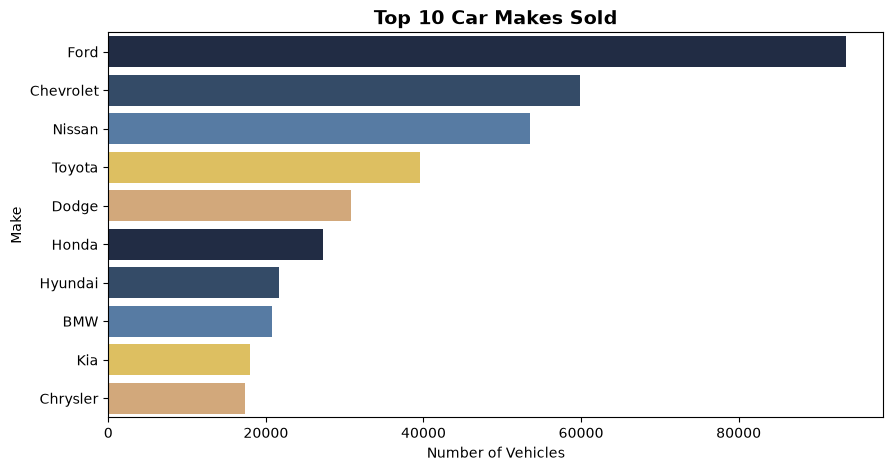

In [7]:
plt.figure(figsize=(10, 5))
top_makes = df['Make'].value_counts().head(10).index
sns.countplot(data=df[df['Make'].isin(top_makes)], y='Make', order=top_makes, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])
plt.title("Top 10 Car Makes Sold", fontsize=14, fontweight='bold')
plt.xlabel("Number of Vehicles")
plt.ylabel("Make")
plt.show()

C:\Users\WorkStation\AppData\Local\Temp\ipykernel_27340\589960010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])
C:\Users\WorkStation\AppData\Local\Temp\ipykernel_27340\589960010.py:5: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=avg_price.index, y=avg_price.values, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])


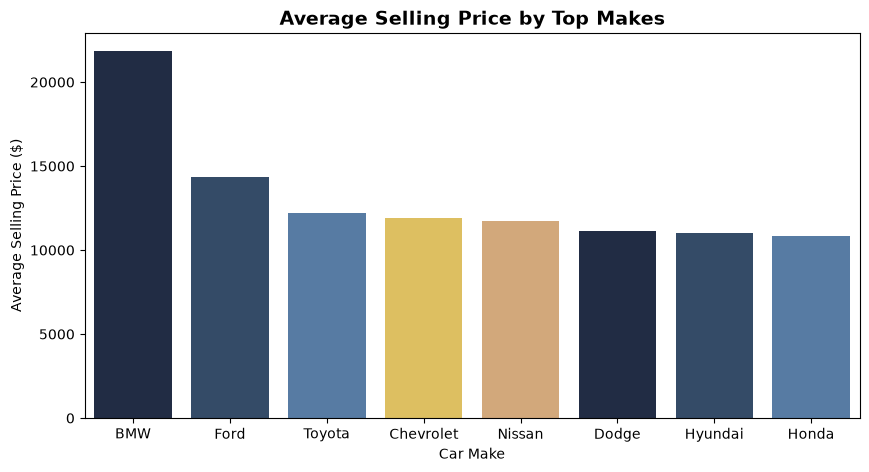

In [8]:
plt.figure(figsize=(10, 5))
top_8 = df['Make'].value_counts().head(8).index
avg_price = df[df['Make'].isin(top_8)].groupby('Make')['SellingPrice'].mean().sort_values(ascending=False)

sns.barplot(x=avg_price.index, y=avg_price.values, palette=['#1B2A4A', '#2C4A6F', '#4A7BB0', '#F2C94C', '#E0A96D'])
plt.title("Average Selling Price by Top Makes", fontsize=14, fontweight='bold')
plt.xlabel("Car Make")
plt.ylabel("Average Selling Price ($)")
plt.show()

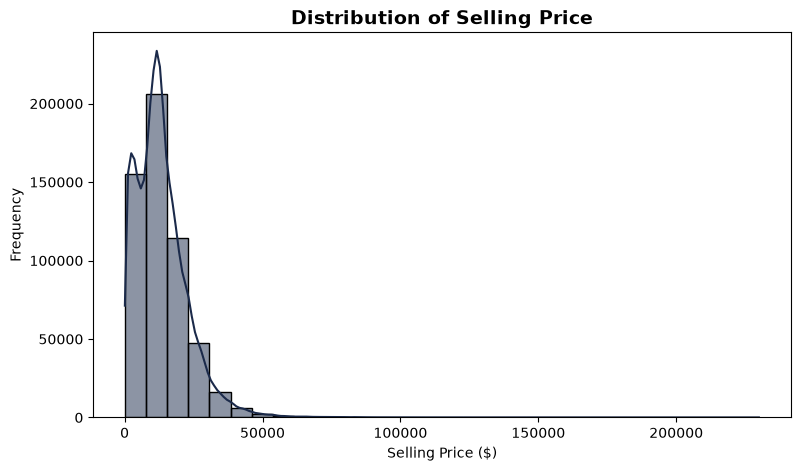

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="SellingPrice", kde=True, color="#1B2A4A", bins=30)
plt.title("Distribution of Selling Price", fontsize=14, fontweight='bold')
plt.xlabel("Selling Price ($)")
plt.ylabel("Frequency")
plt.show()

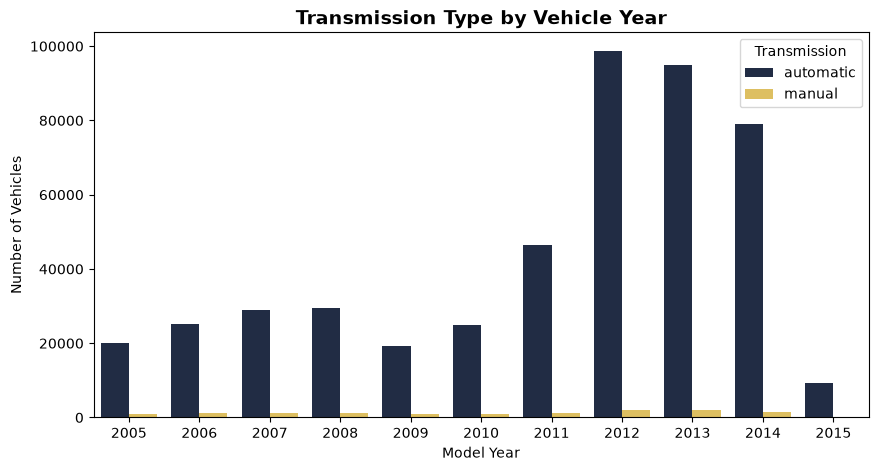

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['Year'] >= 2005], x="Year", hue="Transmission", palette=["#1B2A4A", "#F2C94C"])
plt.title("Transmission Type by Vehicle Year", fontsize=14, fontweight='bold')
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.show()

C:\Users\WorkStation\AppData\Local\Temp\ipykernel_27340\4089301950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Transmission", y="SellingPrice", palette=["#2C4A6F", "#E0A96D"])


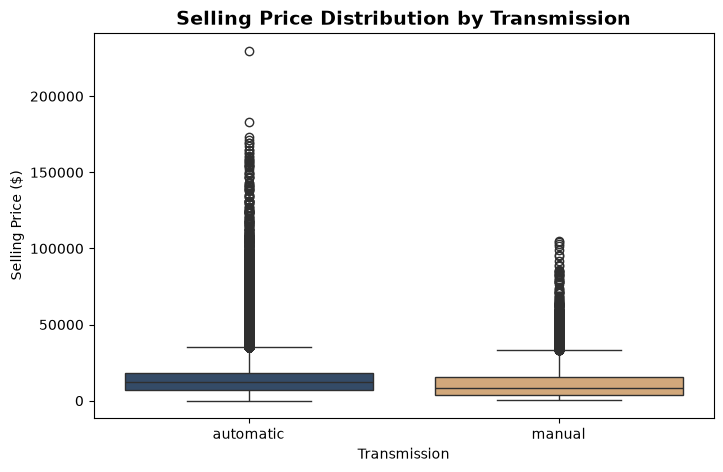

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Transmission", y="SellingPrice", palette=["#2C4A6F", "#E0A96D"])
plt.title("Selling Price Distribution by Transmission", fontsize=14, fontweight='bold')
plt.xlabel("Transmission")
plt.ylabel("Selling Price ($)")
plt.show()

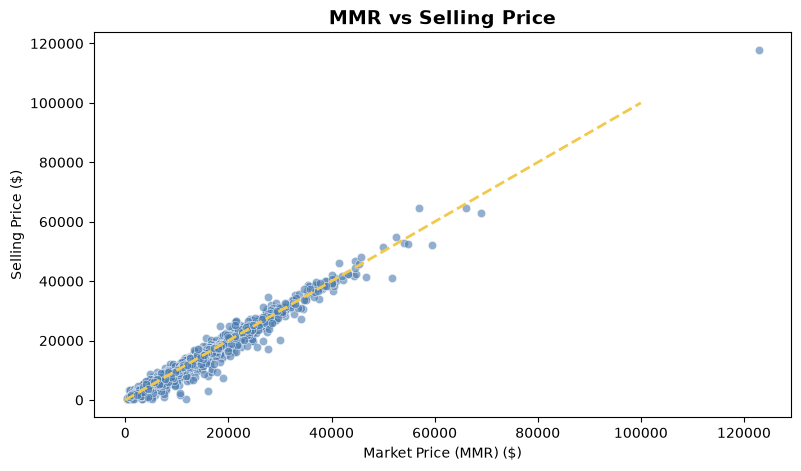

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.sample(2000), x="MMR", y="SellingPrice", color="#4A7BB0", alpha=0.6)
plt.plot([0, 100000], [0, 100000], color="#F2C94C", linestyle="--", linewidth=2)
plt.title("MMR vs Selling Price", fontsize=14, fontweight='bold')
plt.xlabel("Market Price (MMR) ($)")
plt.ylabel("Selling Price ($)")
plt.show()

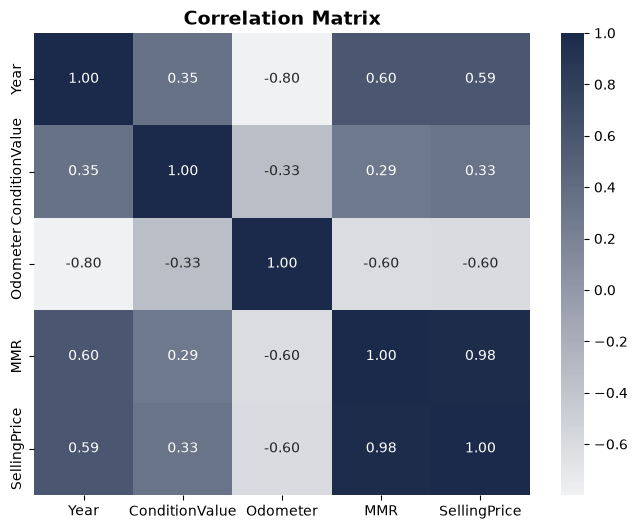

In [13]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['Year', 'ConditionValue', 'Odometer', 'MMR', 'SellingPrice']].corr()
sns.heatmap(numeric_cols, annot=True, cmap=sns.light_palette("#1B2A4A", as_cmap=True), fmt=".2f")
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

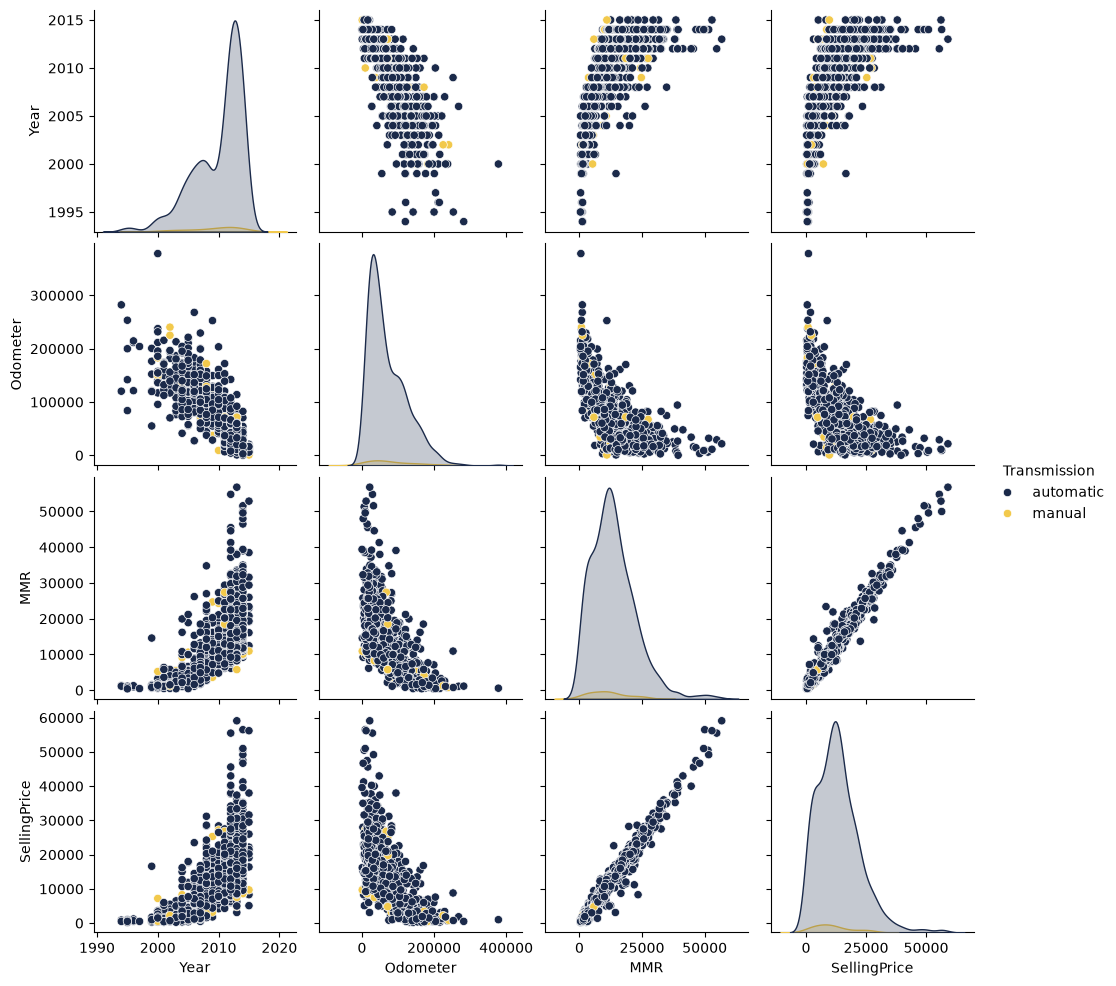

In [14]:
sample_df = df[['Year', 'Odometer', 'MMR', 'SellingPrice', 'Transmission']].dropna().sample(1000)
sns.pairplot(sample_df, hue="Transmission", palette=["#1B2A4A", "#F2C94C"])
plt.show()

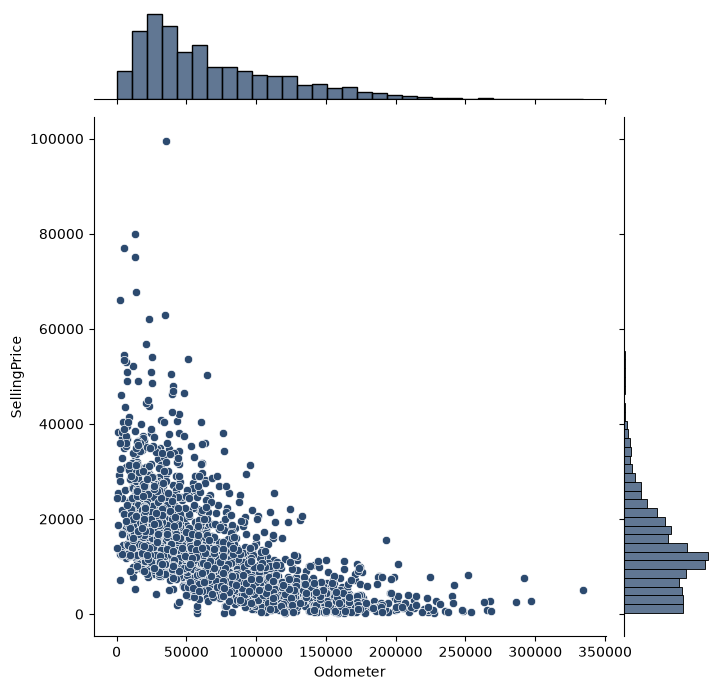

In [15]:
sns.jointplot(data=df.sample(2000), x="Odometer", y="SellingPrice", color="#2C4A6F", kind="scatter", height=7)
plt.show()